# Sobol Sampling for Sensitivity Analysis on AlphaPEM
 
In this step, we directly generate the parameter samples needed for first- and second-order Sobol sensitivity analysis of the **AlphaPEM** model.

 - We work with a configuration file (`param_config.yaml`) that defines the ranges for all input parameters.
 - We include handling for **dependent parameters**, e.g., `Pc_des = Pa_des - 20000`.
 - The final output is a Pandas DataFrame (`df_sobol_samples`) with `2N*(D + 2)` rows (where `D` is the number of parameters).
 
This matrix can then be passed to the AlphaPEM model to evaluate polarization curves and compute sensitivity indices.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import hashlib
from omegaconf import OmegaConf
from SALib.sample import saltelli
from SALib.sample.sobol import sample as sobol_sample
from SALib.analyze import sobol
import pickle
import xgboost as xgb

# Custom modules
sys.path.append("../external/AlphaPEM")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

In [2]:
def compute_region_auc(row, ifc_cols, ucell_cols, region_bounds, handle_negative="drop"):
    """
    Compute the discrete AUC for one region of the polarization curve.

    Parameters
    ----------
    row : pd.Series
        One row from the dataset.
    ifc_cols : list of str
        Columns containing current density values.
    ucell_cols : list of str
        Columns containing voltage values.
    region_bounds : tuple
        Tuple (lower_bound, upper_bound) for the region.
    handle_negative : str
        What to do with negative voltages:
        - 'drop': ignore (mask out) those points
        - 'zero': replace them with 0
        - 'keep': use as-is (default behavior)

    Returns
    -------
    float or np.nan
        Computed area under the curve for the given region.
    """
    import numpy as np

    ifcs = row[ifc_cols].values
    volts = row[ucell_cols].values
    mask_region = (ifcs >= region_bounds[0]) & (ifcs < region_bounds[1])

    if not np.any(mask_region):
        return np.nan

    region_ifcs = ifcs[mask_region]
    region_volts = volts[mask_region]

    if handle_negative == "drop":
        mask_valid = region_volts >= 0
        region_ifcs = region_ifcs[mask_valid]
        region_volts = region_volts[mask_valid]
    elif handle_negative == "zero":
        region_volts = np.maximum(region_volts, 0)

    if len(region_ifcs) < 2:
        return np.nan  # Need at least two points to integrate

    return np.trapezoid(region_volts, region_ifcs)

In [3]:
# -------------------------------------
# Load parameter configuration
# -------------------------------------
config_path = '../param_config.yaml'
parameter_ranges = OmegaConf.load(config_path)
param_dict = dict(parameter_ranges)
print(f"Loaded the parameter ranges for {len(param_dict)} input features.")
print(param_dict)

Loaded the parameter ranges for 13 input features.
{'Tfc': [333, 363], 'Pa_des': [130000.0, 300000.0], 'Sc': [1.1, 3.0], 'Phi_c_des': [0.1, 0.7], 'epsilon_gdl': [0.55, 0.8], 'tau': [1.0, 4.0], 'epsilon_mc': [0.15, 0.4], 'epsilon_c': [0.15, 0.3], 'e': [3, 4, 5], 'Re': [5e-07, 5e-06], 'i0_c_ref': [0.001, 80], 'kappa_co': [15, 40], 'kappa_c': [0, 2.5]}


In [4]:
# -------------------------------------
# Identify discrete parameters
# -------------------------------------
discrete_values_dict = {}
processed_bounds = {}

for param, values in param_dict.items():
    if len(values) > 2:
        # Discrete: Store list of valid values, use min/max as bounds
        discrete_values_dict[param] = values
        processed_bounds[param] = [min(values), max(values)]
    else:
        # Continuous: Use as-is
        processed_bounds[param] = values

In [5]:
# -------------------------------------
# Define SALib problem dictionary
# -------------------------------------
param_names = list(processed_bounds.keys())
bounds = [processed_bounds[name] for name in param_names]

problem = {
    'num_vars': len(param_names),
    'names': param_names,
    'bounds': bounds
}

In [6]:
# -------------------------------------
# Generate Sobol Samples
# -------------------------------------
N = 2048

X = sobol_sample(problem, N, calc_second_order=True, seed=42)

# Convert to DataFrame
df_param_values = pd.DataFrame(X, columns=param_names)
df_param_values.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265


In [7]:
nconfigs_total = len(df_param_values)
print(nconfigs_total)

57344


In [8]:
# -------------------------------------
# Post-process discrete variables
# -------------------------------------
df_param_values_final = df_param_values.copy()

for param, valid_values in discrete_values_dict.items():
    df_param_values_final[param] = df_param_values_final[param].apply(
        lambda x: min(valid_values, key=lambda v: abs(v - x))
    )

# -------------------------------------
# Add dependent parameters
# -------------------------------------
df_param_values_final["Pc_des"] =  df_param_values_final["Pa_des"] - 20000

In [9]:
def row_hash(row):
    row_str = '|'.join([f"{x:.8g}" for x in row])
    return hashlib.sha256(row_str.encode()).hexdigest()

df_param_values_final["config_id"] = df_param_values_final[param_names].apply(row_hash, axis=1)
df_param_values_final["index"] = df_param_values_final.index
df_param_values_final.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des,config_id,index
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,0
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,1
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,181916.980138,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,2
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,55ffdc9133539a01473597aeab35970e09c730c6d41260...,3
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,4


In [ ]:
# Save the design matrix for the sampling
# df_param_values_final.to_pickle("../data/raw/nathaly_sobol_design_matrix.pkl")

## Begin the analysis

### Data analysis

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# --- Step 1: Define paths ---
results_folder = "../data/raw/temp_samples_nathaly_sobol" 
design_matrix_path = "../data/raw/nathaly_sobol_design_matrix.pkl"

print(f"Loaded design matrix with {len(df_param_values_final)} rows.")

Loaded design matrix with 57344 rows.


In [12]:
dfs = []
for file in os.listdir(results_folder):
    if file.endswith(".pkl"):
        path = os.path.join(results_folder, file)
        try:
            df = pd.read_pickle(path)
            dfs.append(df)
            print(f"Loaded: {file} with {len(df)} rows.")
        except Exception as e:
            print(f"Failed to load {file}: {e}")

df_results = pd.concat(dfs, ignore_index=True)
print("-------------------------------------------------")
print(f"Total concatenated results: {len(df_results)}")

Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core0.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core1.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core2.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core3.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core4.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core5.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core6.pkl with 325 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_for_N1024_missing_2598_offset0_core7.pkl with 323 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_offset0_core0.pkl with 1131 rows.
Loaded: worker_temp_nathaly_missing_design_matrix_offset0_core1.pkl 

In [13]:
# --- Step 4: Remove duplicates based on config_id and index ---
df_results = df_results.drop_duplicates(subset=["config_id", "index"])
print(f"After removing duplicates: {len(df_results)}")

After removing duplicates: 33072


In [14]:
df_results.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Sa,Phi_a_des,a_slim,b_slim,a_switch,ifc,Ucell,SHA256,config_id,index
0,342.224261,280108.099058,1.537243,0.184720,0.732007,1.629209,0.385605,0.240976,4,8.668584e-07,...,1.3,0.5,0,1,0.99,"[0.0008240243289084734, 0.100822669922797, 0.2...","[0.994461179250021, 0.9441137804502849, 0.9153...",None,ed90ad3292ae34bb0436d96363519c894d71f34e58eb24...,24874
1,342.224261,280108.099058,1.537243,0.184720,0.732007,1.629209,0.385605,0.240976,4,4.111588e-06,...,1.3,0.5,0,1,0.99,"[0.0008240276799588997, 0.10082267327940106, 0...","[0.9709775255652122, 0.9170699916248938, 0.884...",None,76595b4ee64aaf4072914cf598ab2be6bb0694716f60fe...,24875
2,342.224261,280108.099058,1.537243,0.184720,0.732007,1.629209,0.385605,0.240976,4,4.111588e-06,...,1.3,0.5,0,1,0.99,"[0.0008056827492680994, 0.10080429725399034, 0...","[0.9476850212017883, 0.9116546806288147, 0.885...",None,0485b07f39f2819ae93f60889d293b1cc144afc22841ee...,24876
3,342.224261,280108.099058,1.537243,0.184720,0.732007,1.629209,0.385605,0.240976,4,4.111588e-06,...,1.3,0.5,0,1,0.99,"[0.0008118886240440546, 0.1008105138050188, 0....","[1.1494636116993193, 1.0930650885159134, 1.059...",None,4e936fc74baed1597c506d6a285a6dcf2d05ea2c6a4f3a...,24877
4,342.224261,133519.845493,2.610430,0.614784,0.740595,3.830544,0.353354,0.252067,4,8.668584e-07,...,1.3,0.5,0,1,0.99,"[0.0008090733854771436, 0.10080769374356358, 0...","[1.0261453220238554, 0.957127735468104, 0.9167...",None,c56dc4cb2f9b024a14f1c3393352c6da98a9199c912db7...,24878


In [65]:
df_results.to_pickle("../data/raw/sampled_nathaly_sobol_design_matrix_forN1024.pkl")

In [15]:
# --- Step 5: Merge with design matrix ---
df_merged = df_param_values_final[df_param_values_final["index"] <= nconfigs_total/2][["config_id", "index"] + param_names].merge(
    df_results.drop(columns= param_names),
    on=["config_id", "index"],
    how="left",
    indicator=True
)

print(len(df_merged))

# --- Step 6: Flag missing rows ---
missing_mask = df_merged["_merge"] == "left_only"
missing_count = missing_mask.sum()
print(f"Missing evaluations: {missing_count} out of {len(df_merged)}")

28673
Missing evaluations: 0 out of 28673


In [16]:
df_merged.columns

Index(['config_id', 'index', 'Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl',
       'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co',
       'kappa_c', 'Pc_des', 't_step', 'i_step', 'delta_pola', 'i_EIS',
       'ratio_EIS', 'f_EIS', 't_EIS', 'current_density', 'max_step', 'n_gdl',
       't_purge', 'type_fuel_cell', 'type_current', 'type_auxiliary',
       'type_control', 'type_purge', 'type_display', 'type_plot', 'C_scl',
       'i_max_pola', 'Aact', 'Hgdl', 'Hmem', 'Hcl', 'Hgc', 'Wgc', 'Lgc', 'Sa',
       'Phi_a_des', 'a_slim', 'b_slim', 'a_switch', 'ifc', 'Ucell', 'SHA256',
       '_merge'],
      dtype='object')

In [18]:
# --- Step 6: Flag and extract missing configs ---
df_merged["missing"] = (df_merged["_merge"] == "left_only").astype(int)
missing_df = df_merged[df_merged["missing"] == 1].copy()
missing_df = missing_df.drop(columns=["_merge", "missing"])

missing_df = df_param_values_final[df_param_values_final["index"].isin(df_merged[df_merged["_merge"] == "left_only"]["index"])].copy()

print(f"[INFO] Missing configurations: {len(missing_df)}")

[INFO] Missing configurations: 0


In [227]:
# --- Step 7: Save missing configurations ---
output_missing_path = "../data/raw/nathaly_missing_design_matrix_for_N1024_missing_2598.pkl"

missing_df.to_pickle(output_missing_path)
print(f"[INFO] Saved missing configurations to: {output_missing_path}")

[INFO] Saved missing configurations to: ../data/raw/nathaly_missing_design_matrix_for_N1024_missing_2598.pkl


In [19]:
import plotly.express as px

# --- Step 8: Interactive plot with Plotly ---
fig = px.scatter(
    df_merged,
    x="index",
    y="missing",
    title="Missing Simulations by Index",
    labels={"index": "Design Matrix Index", "missing": "Missing (1=True)"},
    color="missing",
    height=400
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(yaxis=dict(tickvals=[0, 1]), showlegend=False)
fig.show()

## Previous

In [20]:
# -------------------------------------
# Generate Sobol Samples
# -------------------------------------
N = 1024

X_N1024 = sobol_sample(problem, N, calc_second_order=True, seed=42)

# Convert to DataFrame
df_param_values_N1024 = pd.DataFrame(X_N1024, columns=param_names)
df_param_values_N1024.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265


In [90]:
xgb_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
# --- Load model ---
with open("../results/sm/xgboost/xgb_nconfig_50000_no_neg_with_outerCV_final_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

combined_df = df_merged.copy()

# --- Identify param columns ---
param_cols = param_names

# --- Use a reference ifc from first valid row ---
valid_ifc_row = combined_df["ifc"].dropna().iloc[0]
ref_ifc = valid_ifc_row if isinstance(valid_ifc_row, list) else valid_ifc_row.tolist()

# --- Split rows ---
df_missing = combined_df[combined_df["Ucell"].isna()].copy()
print("Missing configurations:", len(df_missing), "out of", len(combined_df))
df_valid   = combined_df[~combined_df["Ucell"].isna()].copy()

# --- Predict Ucell for missing ---
repeated_ifcs = []
repeated_inputs = []

for _, row in df_missing.iterrows():
    param_values = row[param_cols].values
    ifc_values = row["ifc"] if isinstance(row["ifc"], list) else ref_ifc

    n = len(ifc_values)
    repeated_params = np.tile(param_values, (n, 1))
    ifc_array = np.array(ifc_values).reshape(-1, 1).astype(np.float32)

    X_pred = np.hstack([repeated_params, ifc_array])
    ucell_pred = xgb_model.predict(X_pred)

    row["ifc"] = ifc_values
    row["Ucell"] = ucell_pred.tolist()
    repeated_ifcs.append(row["ifc"])
    repeated_inputs.append(row["Ucell"])

df_missing["ifc"] = repeated_ifcs
df_missing["Ucell"] = repeated_inputs

# --- Merge back ---
combined_df = pd.concat([df_valid, df_missing], ignore_index=True)


# Expand 'ifc' column
if "ifc" in combined_df.columns:
    ifc_expanded = pd.DataFrame(combined_df["ifc"].tolist(), index=combined_df.index)
    ifc_expanded.columns = [f"ifc_{i+1}" for i in range(ifc_expanded.shape[1])]
    combined_df = pd.concat([combined_df.drop(columns=["ifc"]), ifc_expanded], axis=1)

# Expand 'Ucell' column
if "Ucell" in combined_df.columns:
    ucell_expanded = pd.DataFrame(combined_df["Ucell"].tolist(), index=combined_df.index)
    ucell_expanded.columns = [f"Ucell_{i+1}" for i in range(ucell_expanded.shape[1])]
    combined_df = pd.concat([combined_df.drop(columns=["Ucell"]), ucell_expanded], axis=1)

ifc_columns = [col for col in combined_df.columns if col.startswith("ifc_")]
ucell_columns = [col for col in combined_df.columns if col.startswith("Ucell_")]

combined_df = combined_df[["index", "config_id"] + param_names + ifc_columns + ucell_columns].sort_values(by = "index", ascending= True).copy()

Missing configurations: 24 out of 28673


In [22]:
combined_df.head()

,index,config_id,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,Ucell_31
0,0,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.739045,0.729589,0.720136,0.710694,0.701276,0.691868,0.682447,0.672998,0.663503,0.653945
1,1,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.721294,0.714532,0.707312,0.699526,0.691418,0.682971,0.674209,0.665224,0.656077,0.646728
2,2,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.671937,0.674898,0.678610,0.672720,0.664524,0.658328,0.651773,0.644676,0.636803,0.628512
3,3,55ffdc9133539a01473597aeab35970e09c730c6d41260...,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.726462,0.716607,0.706750,0.696888,0.686996,0.677051,0.667036,0.656930,0.646715,0.636370
4,4,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,...,0.738852,0.729371,0.719911,0.710484,0.701083,0.691683,0.682266,0.672816,0.663316,0.653751


In [23]:
def plot_polarization_curves(rows, print_legend = True, id_name = "index"):
    plt.figure(figsize=(8, 5))

    for _, row in rows.iterrows():
        ucell_cols = [col for col in row.index if col.startswith("Ucell_")]
        ifc_cols = [col for col in row.index if col.startswith("ifc_")]

        voltages = row[ucell_cols].values.astype(float)
        current_densities = row[ifc_cols].values.astype(float)

        plt.plot(current_densities, voltages, marker='o', label=f"ID: {row[id_name]}")

    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title("Polarization curve")
    plt.xlabel(r"Current density $i_{fc}$ (A.cm$^{-2}$)")
    plt.ylabel(r"Cell voltage $U_{cell}$ (V)")
    plt.grid(True)
    if print_legend: 
        plt.legend()
    plt.tight_layout()
    plt.show()

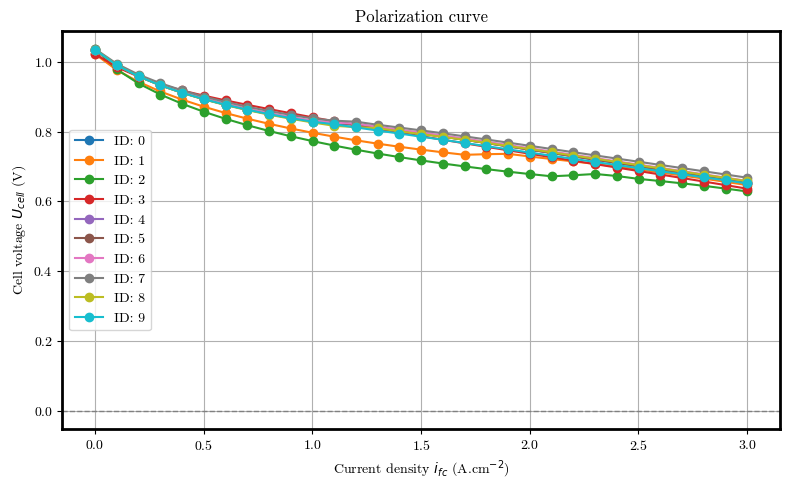

In [24]:
plot_polarization_curves(combined_df.iloc[:10])

### Analysis of the samples we already have

In [25]:
combined_df.head()

,index,config_id,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,Ucell_31
0,0,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.739045,0.729589,0.720136,0.710694,0.701276,0.691868,0.682447,0.672998,0.663503,0.653945
1,1,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.721294,0.714532,0.707312,0.699526,0.691418,0.682971,0.674209,0.665224,0.656077,0.646728
2,2,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.671937,0.674898,0.678610,0.672720,0.664524,0.658328,0.651773,0.644676,0.636803,0.628512
3,3,55ffdc9133539a01473597aeab35970e09c730c6d41260...,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.726462,0.716607,0.706750,0.696888,0.686996,0.677051,0.667036,0.656930,0.646715,0.636370
4,4,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,...,0.738852,0.729371,0.719911,0.710484,0.701083,0.691683,0.682266,0.672816,0.663316,0.653751


28672.0

In [29]:
df_sampled = combined_df[combined_df["index"] < nconfigs_total /2].copy()
len(df_sampled)

28672

In [30]:
ifc_cols = [col for col in df_sampled.columns if col.startswith("ifc_")]
ucell_cols = [col for col in df_sampled.columns if col.startswith("Ucell_")]

REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

In [31]:
region_name = "activation"
region_bounds = REGIONS[region_name]   
# Compute region-specific AUC
target_name = f"AUC_{region_name}"
print(f"[INFO] Computing AUC target for region: {region_name}")
df_sampled[target_name] = df_sampled.apply(
    compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds, "zero")
)

[INFO] Computing AUC target for region: activation


In [32]:
df_sampled.head()

,index,config_id,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,...,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,Ucell_31,AUC_activation
0,0,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.729589,0.720136,0.710694,0.701276,0.691868,0.682447,0.672998,0.663503,0.653945,0.293051
1,1,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.714532,0.707312,0.699526,0.691418,0.682971,0.674209,0.665224,0.656077,0.646728,0.288595
2,2,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.674898,0.678610,0.672720,0.664524,0.658328,0.651773,0.644676,0.636803,0.628512,0.288623
3,3,55ffdc9133539a01473597aeab35970e09c730c6d41260...,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,...,0.716607,0.706750,0.696888,0.686996,0.677051,0.667036,0.656930,0.646715,0.636370,0.291976
4,4,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,...,0.729371,0.719911,0.710484,0.701083,0.691683,0.682266,0.672816,0.663316,0.653751,0.293121


In [33]:
Y = df_sampled[target_name].to_numpy()

In [34]:
type(Y)

numpy.ndarray

In [35]:
len(Y)

28672

In [36]:
Y

array([0.29305141, 0.28859459, 0.28862307, ..., 0.30071825, 0.29498808,
       0.30522678], shape=(28672,))

In [37]:
Si = sobol.analyze(
    problem,
    Y,
    calc_second_order=True,   # or False, depending on what you want
    print_to_console=True     # optional
)

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



                   ST       ST_conf
Tfc          0.093942  9.145244e-03
Pa_des       0.076079  1.089349e-02
Sc           0.014239  1.979869e-03
Phi_c_des    0.001109  2.557679e-04
epsilon_gdl  0.000058  1.159155e-05
tau          0.005091  7.253191e-04
epsilon_mc   0.003656  5.712236e-04
epsilon_c    0.000003  8.250257e-07
e            0.002921  5.755204e-03
Re           0.002019  2.133347e-04
i0_c_ref     0.549654  4.947003e-02
kappa_co     0.024304  2.284355e-03
kappa_c      0.262440  3.090191e-02
                   S1   S1_conf
Tfc          0.088424  0.024570
Pa_des       0.061499  0.024980
Sc           0.007252  0.010126
Phi_c_des   -0.000683  0.002632
epsilon_gdl -0.000031  0.000620
tau          0.004863  0.006723
epsilon_mc   0.002299  0.005353
epsilon_c   -0.000051  0.000109
e           -0.000804  0.002050
Re           0.002787  0.003784
i0_c_ref     0.560682  0.081900
kappa_co     0.024019  0.013879
kappa_c      0.233816  0.045228
                            S2   S2_conf
(Tfc, P

In [38]:
total_Si, first_Si, second_Si = Si.to_df()

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [39]:
first_Si.sort_values(by = "S1", ascending=False)

,S1,S1_conf
i0_c_ref,0.560682,0.081900
kappa_c,0.233816,0.045228
Tfc,0.088424,0.024570
Pa_des,0.061499,0.024980
kappa_co,0.024019,0.013879
Sc,0.007252,0.010126
tau,0.004863,0.006723
Re,0.002787,0.003784
epsilon_mc,0.002299,0.005353
epsilon_gdl,-0.000031,0.000620


In [62]:
print("Sum of S1 indices:", round(sum(first_Si["S1"]),3))
print("Sum of S1 indices (setting negative indices to 0):", round(first_Si[first_Si["S1"] > 0]["S1"].sum(),3))

Sum of S1 indices: 0.984
Sum of S1 indices (setting negative indices to 0): 0.986


In [ ]:
print("Sum of second order:", sum(second_Si["S2"]))
print("Sum of second order:", sum(second_Si[second_Si["S2"] > 0]["S2"]))
second_Si

Sum of second order: -0.13730349227988745
Sum of second order: 0.10195610748096691


,S2,S2_conf
"(Tfc, Pa_des)",0.002401,0.036580
"(Tfc, Sc)",0.003024,0.038273
"(Tfc, Phi_c_des)",0.002892,0.038619
"(Tfc, epsilon_gdl)",0.002991,0.038522
"(Tfc, tau)",0.002703,0.038310
...,...,...
"(Re, kappa_co)",-0.001269,0.005261
"(Re, kappa_c)",-0.001306,0.005741
"(i0_c_ref, kappa_co)",-0.015152,0.137531
"(i0_c_ref, kappa_c)",-0.020094,0.134312


In [59]:
print("Sum of S1 and S2:", sum(first_Si["S1"]) + sum(second_Si["S2"]))
print(sum(second_Si[second_Si["S2"] > 0]["S2"]) + sum(first_Si[first_Si["S1"] > 0]["S1"]))

Sum of S1 and S2: 0.8467705659627026
1.0875985842255427


In [55]:
for i, name in enumerate(problem['names']):
    print(f"{name:12s} | S1 = {Si['S1'][i]:.3f} ± {Si['S1_conf'][i]:.3f}, "
          f"ST = {Si['ST'][i]:.3f} ± {Si['ST_conf'][i]:.3f}")

Tfc          | S1 = 0.088 ± 0.025, ST = 0.094 ± 0.009
Pa_des       | S1 = 0.061 ± 0.025, ST = 0.076 ± 0.011
Sc           | S1 = 0.007 ± 0.010, ST = 0.014 ± 0.002
Phi_c_des    | S1 = -0.001 ± 0.003, ST = 0.001 ± 0.000
epsilon_gdl  | S1 = -0.000 ± 0.001, ST = 0.000 ± 0.000
tau          | S1 = 0.005 ± 0.007, ST = 0.005 ± 0.001
epsilon_mc   | S1 = 0.002 ± 0.005, ST = 0.004 ± 0.001
epsilon_c    | S1 = -0.000 ± 0.000, ST = 0.000 ± 0.000
e            | S1 = -0.001 ± 0.002, ST = 0.003 ± 0.006
Re           | S1 = 0.003 ± 0.004, ST = 0.002 ± 0.000
i0_c_ref     | S1 = 0.561 ± 0.082, ST = 0.550 ± 0.049
kappa_co     | S1 = 0.024 ± 0.014, ST = 0.024 ± 0.002
kappa_c      | S1 = 0.234 ± 0.045, ST = 0.262 ± 0.031


In [230]:
first_Si.sort_values(by = "S1", ascending = False)

,S1,S1_conf
i0_c_ref,0.560277,0.091487
kappa_c,0.232271,0.040958
Tfc,0.091070,0.025815
Pa_des,0.057997,0.019759
kappa_co,0.019533,0.015900
epsilon_mc,0.006698,0.012134
tau,0.004574,0.008549
Sc,0.003412,0.013843
e,0.000805,0.004341
Re,-0.000623,0.005612


In [216]:
total_Si.sort_values(by = "ST", ascending = False)

,ST,ST_conf
i0_c_ref,0.549645,0.049051
kappa_c,0.264944,0.030988
Tfc,0.098680,0.011328
Pa_des,0.077347,0.012553
kappa_co,0.025637,0.002833
Sc,0.015056,0.002324
epsilon_mc,0.007267,0.004087
tau,0.006434,0.001848
Phi_c_des,0.005511,0.006216
e,0.005140,0.005887


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

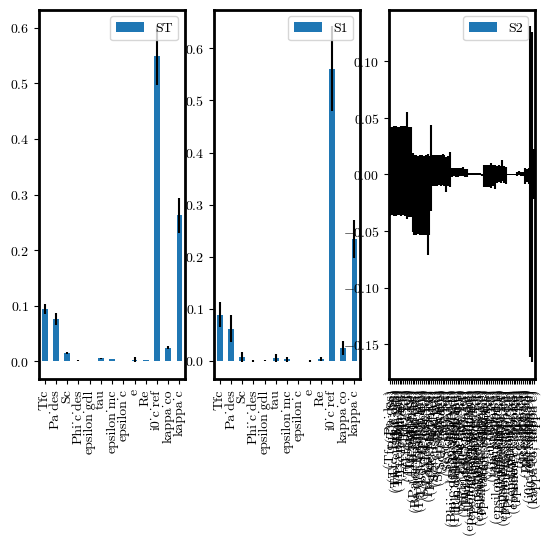

In [58]:
Si.plot()

In [57]:
# Settings
D = 13
step = 128  # step size for N (e.g., 128, 256, 512, ...)
max_N = 1024
samples_per_N = 2*D + 2
N_values = list(range(step, max_N + 1, step))

# Store convergence data
st_convergence = {name: [] for name in problem['names']}
n_effective = []

for N_i in N_values:
    end_idx = N_i * samples_per_N
    Y_subset = Y[:end_idx]
    
    try:
        Si = sobol.analyze(problem, Y_subset, calc_second_order=True, print_to_console=False)
        for i, name in enumerate(problem['names']):
            st_convergence[name].append(Si['ST'][i])
        n_effective.append(N_i)
    except Exception as e:
        print(f"Failed at N={N_i}: {e}")


import plotly.graph_objects as go

fig = go.Figure()

for name in problem['names']:
    fig.add_trace(go.Scatter(
        x=n_effective,
        y=st_convergence[name],
        mode='lines+markers',
        name=name
    ))

fig.update_layout(
    title='Convergence of Total Sobol Indices (ST) vs. Sample Size',
    xaxis_title='N (base sample size)',
    yaxis_title='Sobol ST index',
    hovermode='x unified',
    legend=dict(
        orientation='v',
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top'
    ),
    width=1000,
    height=600,
    margin=dict(r=150)
)

fig.show()